In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df = df[['v1', 'v2']]
df.columns = ['Category', 'Message']
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
print(df['Category'].value_counts())

Category
ham     4825
spam     747
Name: count, dtype: int64


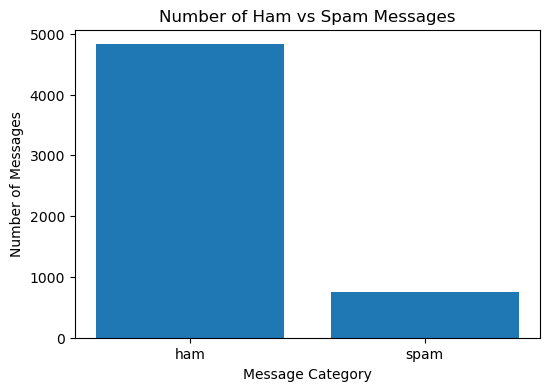

In [7]:
counts = df['Category'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(counts.index, counts.values)

plt.title("Number of Ham vs Spam Messages")
plt.xlabel("Message Category")
plt.ylabel("Number of Messages")

plt.show()

In [8]:
df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})

In [9]:
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
X = df['Message']
y = df['Category']

In [11]:
X.head()

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: Message, dtype: object

In [12]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Category, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [14]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [15]:
vectorizer = CountVectorizer(stop_words='english')

In [16]:
X_train_vectors = vectorizer.fit_transform(X_train)

In [17]:
X_test_vectors = vectorizer.transform(X_test)

In [18]:
print("Training vector shape:", X_train_vectors.shape)
print("Testing vector shape:", X_test_vectors.shape)

Training vector shape: (4457, 7440)
Testing vector shape: (1115, 7440)


In [19]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vectors, y_train)

LogisticRegression(max_iter=1000)

In [20]:
predictions = model.predict(X_test_vectors)

In [21]:
print(predictions[:20])

[0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [22]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9766816143497757
Accuracy percentage: 97.66816143497758 %


In [23]:
cm = confusion_matrix(y_test, predictions)
print(cm)

[[966   0]
 [ 26 123]]


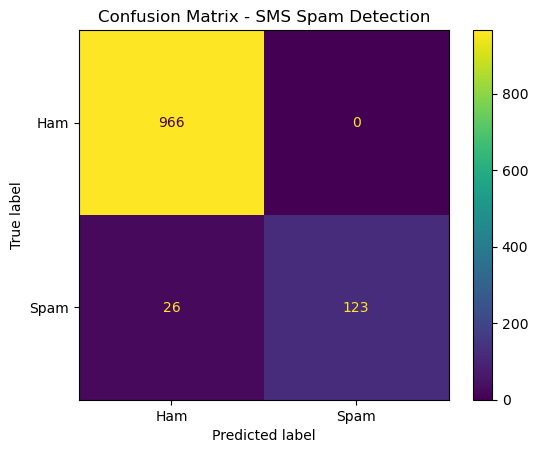

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()

plt.title("Confusion Matrix - SMS Spam Detection")
plt.show()

In [25]:
correct_predictions = (y_test == predictions).sum()
print("Correctly classified messages:", correct_predictions)

Correctly classified messages: 1089


In [26]:
print("Total test messages:", len(y_test))

Total test messages: 1115


In [27]:
message = input("Enter an SMS message: ")
message_vector = vectorizer.transform([message])
prediction = model.predict(message_vector)[0]
if prediction == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: HAM")

Prediction: SPAM


# Conclusion

In this project, an SMS Spam Detection system was developed using
Machine Learning.

The SMS messages were converted into numerical features using
CountVectorizer. Logistic Regression was then trained on 80% of
the dataset and evaluated using the remaining 20%.

The model was evaluated using accuracy and a confusion matrix.

The model can also classify new user-entered SMS messages as either
Ham or Spam.

Therefore, Machine Learning can be effectively used for automatic
SMS spam detection.